<a href="https://colab.research.google.com/github/amii-uwl-dba/northstar-analytics/blob/main/1_SQL_R_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
install.packages("sqldf")
install.packages("ggplot2")
install.packages("dplyr")
install.packages("lubridate")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [29]:
library(sqldf)
library(ggplot2)
library(dplyr)
library(lubridate)


Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




In [30]:
base_url <- "https://raw.githubusercontent.com/amii-uwl-dba/northstar-analytics/main/"

deliveries <- read.csv(paste0(base_url, "deliveries.csv"))
complaints <- read.csv(paste0(base_url, "complaints.csv"))
customers <- read.csv(paste0(base_url, "customers.csv"))
drivers <- read.csv(paste0(base_url, "drivers.csv"))
hubs <- read.csv(paste0(base_url, "hubs.csv"))
incidents <- read.csv(paste0(base_url, "incidents.csv"))
orders <- read.csv(paste0(base_url, "orders.csv"))
vehicles <- read.csv(paste0(base_url, "vehicles.csv"))
app_events <- read.csv(paste0(base_url, "app_events.csv"))

In [31]:
colnames(deliveries)
colnames(complaints)
colnames(orders)
colnames(vehicles)

[1] "delivery_id"                   "order_id"                     
 [3] "driver_id"                     "vehicle_id"                   
 [5] "hub_id"                        "dispatch_time"                
 [7] "delivery_completed_at"         "delivery_status"              
 [9] "route_distance_km"             "manual_route_override_count"  
[11] "proof_of_completion_missing"   "customer_rating_post_delivery"
[13] "fuel_or_charge_cost"

[1] "complaint_id"        "customer_id"         "order_id"           
 [4] "complaint_type"      "channel"             "severity"           
 [7] "created_at"          "status"              "resolution_days"    
[10] "compensation_amount"

[1] "order_id"              "customer_id"           "service_type"         
 [4] "order_created_at"      "promised_window_hours" "pickup_zone"          
 [7] "dropoff_zone"          "priority_level"        "order_value"          
[10] "booking_channel"       "special_handling_flag"

[1] "vehicle_id"         "vehicle_type"       "assigned_zone"     
[4] "commission_date"    "battery_health_pct" "odometer_km"       
[7] "maintenance_status" "telematics_version"

In [32]:
deliveries$dispatch_time <- ymd_hms(deliveries$dispatch_time)
deliveries$delivery_completed_at <- ymd_hms(deliveries$delivery_completed_at)

deliveries$delivery_duration_minutes <- as.numeric(
  difftime(
    deliveries$delivery_completed_at,
    deliveries$dispatch_time,
    units = "mins"
  )
)

head(deliveries$delivery_duration_minutes)

[1] 1328.99841  -66.00000   66.53945 1439.13506  242.56885 1711.87308

In [33]:
deliveries <- deliveries %>%
  mutate(
    delivery_duration_minutes = ifelse(
      delivery_duration_minutes < 0,
      NA,
      delivery_duration_minutes
    )
  )

In [35]:
avg_delay <- sqldf("
SELECT hub_id,
AVG(delivery_duration_minutes) AS avg_delivery_duration
FROM deliveries
GROUP BY hub_id
ORDER BY avg_delivery_duration DESC
")

avg_delay

hub_id,avg_delivery_duration
<chr>,<dbl>
H05,693.1980
H04,666.1581
H01,641.0981
H08,633.6294
H07,632.1533
H06,595.0454
H02,568.7369
H03,506.2736


In [36]:
cat("
This result shows which hubs have the longest average delivery duration.
Higher delivery duration may suggest route planning problems, dispatch delays,
traffic issues, or poor hub-level operational control.
")


This result shows which hubs have the longest average delivery duration.
Higher delivery duration may suggest route planning problems, dispatch delays,
traffic issues, or poor hub-level operational control.


In [37]:
complaint_count <- sqldf("
SELECT complaint_type,
COUNT(*) AS total_complaints
FROM complaints
GROUP BY complaint_type
ORDER BY total_complaints DESC
")

complaint_count

complaint_type,total_complaints
<chr>,<int>
Delay,101
MissedPickup,64
AppIssue,53
DriverBehaviour,51
SupportExperience,20
Billing,16
Damage,15


In [38]:
cat("
This result identifies the most common complaint types.
High complaint categories show where customers are most dissatisfied,
such as missed pickups, app issues, or delays.
")


This result identifies the most common complaint types.
High complaint categories show where customers are most dissatisfied,
such as missed pickups, app issues, or delays.


In [39]:
complaint_severity <- sqldf("
SELECT severity,
COUNT(*) AS total_cases,
AVG(resolution_days) AS avg_resolution_days,
AVG(compensation_amount) AS avg_compensation
FROM complaints
GROUP BY severity
ORDER BY total_cases DESC
")

complaint_severity

severity,total_cases,avg_resolution_days,avg_compensation
<chr>,<int>,<dbl>,<dbl>
Medium,172,6.168605,17.36512
High,77,13.116883,38.84794
Low,71,6.563380,9.05600


In [40]:
# query 4
service_value <- sqldf("
SELECT service_type,
COUNT(*) AS total_orders,
AVG(order_value) AS avg_order_value
FROM orders
GROUP BY service_type
ORDER BY avg_order_value DESC
")

service_value

service_type,total_orders,avg_order_value
<chr>,<int>,<dbl>
Passenger,341,96.07364
Business,165,92.24503
Retail,297,90.01367
Parcel,308,87.61565
Medical,139,87.13619


In [41]:
# query 5
hub_status <- sqldf("
SELECT hub_id,
delivery_status,
COUNT(*) AS total_deliveries
FROM deliveries
GROUP BY hub_id, delivery_status
ORDER BY hub_id, total_deliveries DESC
")

hub_status

hub_id,delivery_status,total_deliveries
<chr>,<chr>,<int>
H01,OnTime,93
H01,Delayed,26
H01,Failed,17
H02,OnTime,70
H02,Delayed,26
H02,Failed,10
H03,OnTime,85
H03,Delayed,23
H03,Failed,11


In [42]:
# query 6
vehicle_maintenance <- sqldf("
SELECT vehicle_type,
maintenance_status,
COUNT(*) AS total_vehicles,
AVG(battery_health_pct) AS avg_battery_health,
AVG(odometer_km) AS avg_odometer
FROM vehicles
GROUP BY vehicle_type, maintenance_status
ORDER BY total_vehicles DESC
")

vehicle_maintenance

vehicle_type,maintenance_status,total_vehicles,avg_battery_health,avg_odometer
<chr>,<chr>,<int>,<dbl>,<dbl>
EV,Active,29,83.12593,120892.34
CargoVan,Active,14,76.19286,105834.50
Hybrid,Active,14,71.85833,121092.00
CargoVan,InRepair,12,71.47500,112507.25
Diesel,Active,10,65.42000,80712.80
Hybrid,InRepair,9,82.63333,122359.67
EV,InRepair,8,78.55000,134185.50
Diesel,InRepair,7,75.61429,91508.29
EV,Scheduled,6,82.38333,140850.33


In [43]:
# query 7
incident_summary <- sqldf("
SELECT incident_type,
severity,
COUNT(*) AS total_incidents,
AVG(resolved_hours) AS avg_resolved_hours
FROM incidents
GROUP BY incident_type, severity
ORDER BY total_incidents DESC
")

incident_summary

incident_type,severity,total_incidents,avg_resolved_hours
<chr>,<chr>,<int>,<dbl>
BatteryAlert,Medium,18,11.11250
RouteDeviation,Low,17,16.01765
VehicleFault,Medium,16,5.83750
AppSyncError,Medium,15,11.90769
CustomerNoShow,Low,15,14.14000
ProofMissing,Medium,15,11.04167
CustomerNoShow,Medium,13,14.06154
ProofMissing,Low,13,14.89167
TemperatureIssue,Medium,13,16.32308


In [44]:
# query 8
hub_performance <- sqldf("
SELECT h.hub_name,
h.zone,
h.hub_type,
COUNT(d.delivery_id) AS total_deliveries,
AVG(d.delivery_duration_minutes) AS avg_delivery_duration,
AVG(d.route_distance_km) AS avg_route_distance,
AVG(d.fuel_or_charge_cost) AS avg_fuel_charge_cost
FROM deliveries d
JOIN hubs h
ON d.hub_id = h.hub_id
GROUP BY h.hub_name, h.zone, h.hub_type
ORDER BY avg_delivery_duration DESC
")

hub_performance

hub_name,zone,hub_type,total_deliveries,avg_delivery_duration,avg_route_distance,avg_fuel_charge_cost
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
Central Core,Central,Control,115,693.1980,14.32165,13.68600
West Gate,West,Dispatch,127,666.1581,13.38457,13.16701
North Exchange,North,Dispatch,136,641.0981,13.64331,12.75581
Midtown Relay,Central,Charging,128,633.6294,12.81547,11.70820
Riverside Hub,Riverside,Warehouse,115,632.1533,14.28696,12.92209
Airport Hub,Airport,Dispatch,104,595.0454,14.41221,13.31923
South Link,South,Dispatch,106,568.7369,14.16915,12.56500
East Dock,East,Warehouse,119,506.2736,14.51555,12.74420


In [45]:
#query 9
complaints_by_service <- sqldf("
SELECT o.service_type,
COUNT(c.complaint_id) AS total_complaints,
AVG(c.resolution_days) AS avg_resolution_days,
AVG(c.compensation_amount) AS avg_compensation
FROM complaints c
JOIN orders o
ON c.order_id = o.order_id
GROUP BY o.service_type
ORDER BY total_complaints DESC
")

complaints_by_service

service_type,total_complaints,avg_resolution_days,avg_compensation
<chr>,<int>,<dbl>,<dbl>
Passenger,84,7.738095,20.71912
Retail,83,7.891566,19.05308
Parcel,77,8.337662,20.61479
Business,39,7.948718,20.79128
Medical,37,7.567568,20.55583


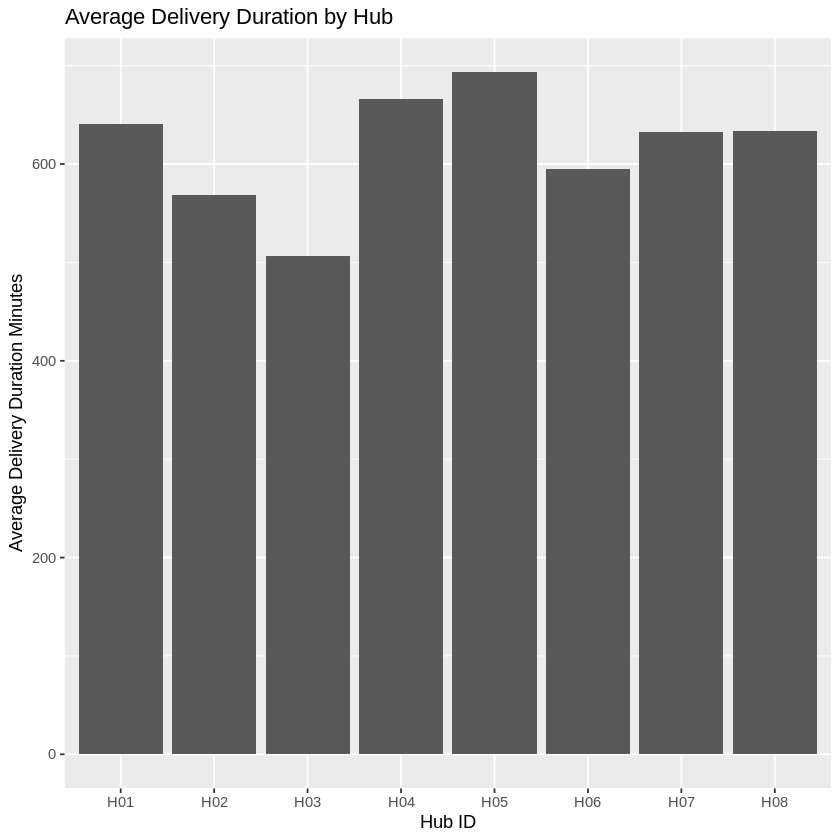

In [46]:
# chart 1
ggplot(avg_delay, aes(x = hub_id, y = avg_delivery_duration)) +
  geom_bar(stat = "identity") +
  labs(
    title = "Average Delivery Duration by Hub",
    x = "Hub ID",
    y = "Average Delivery Duration Minutes"
  )

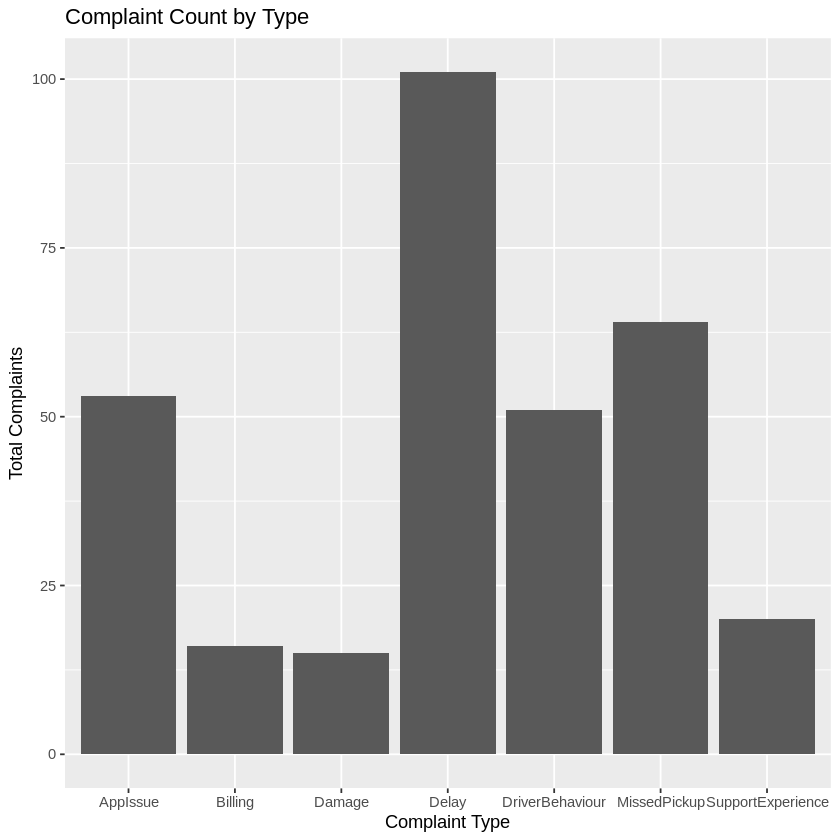

In [47]:
# chart 2
ggplot(complaint_count, aes(x = complaint_type, y = total_complaints)) +
  geom_bar(stat = "identity") +
  labs(
    title = "Complaint Count by Type",
    x = "Complaint Type",
    y = "Total Complaints"
  )

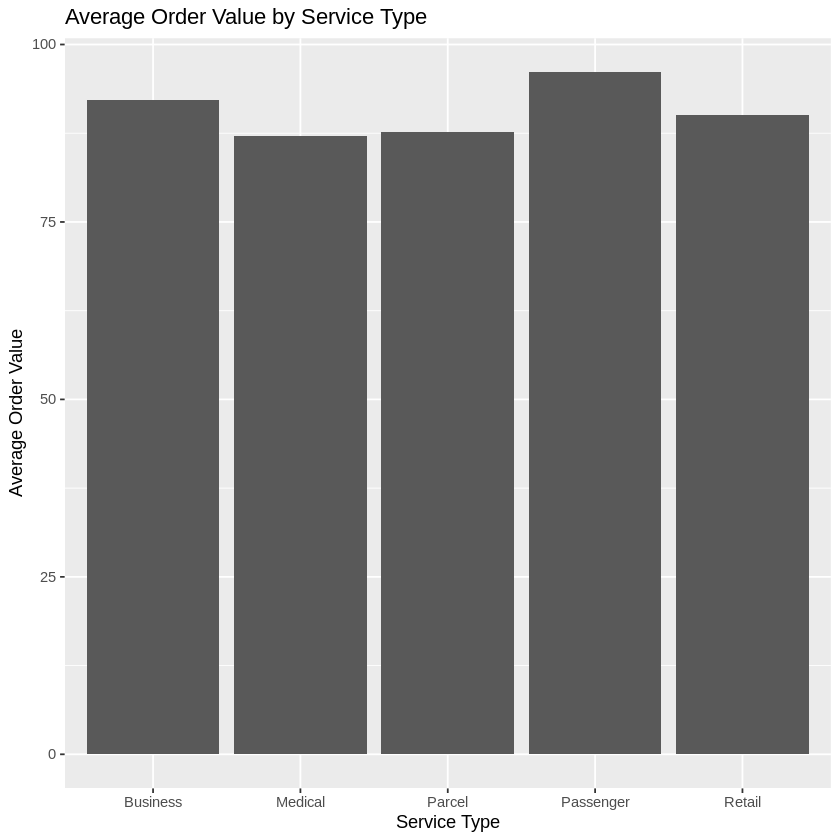

In [48]:
# chart 3
ggplot(service_value, aes(x = service_type, y = avg_order_value)) +
  geom_bar(stat = "identity") +
  labs(
    title = "Average Order Value by Service Type",
    x = "Service Type",
    y = "Average Order Value"
  )

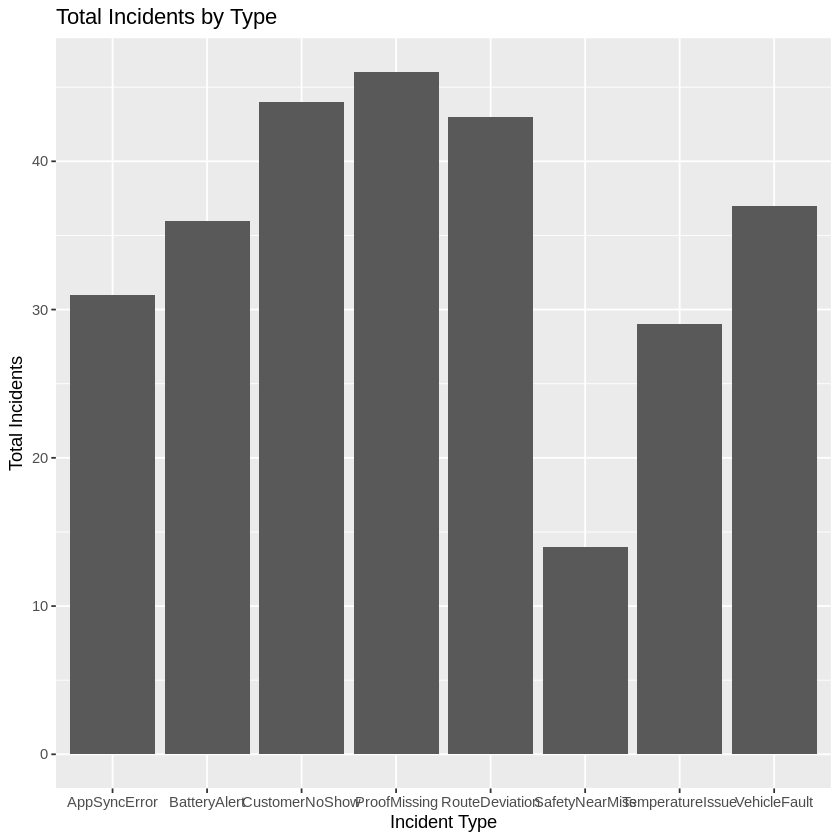

In [49]:
# chart 4
incident_type_count <- sqldf("
SELECT incident_type,
COUNT(*) AS total_incidents
FROM incidents
GROUP BY incident_type
ORDER BY total_incidents DESC
")

ggplot(incident_type_count, aes(x = incident_type, y = total_incidents)) +
  geom_bar(stat = "identity") +
  labs(
    title = "Total Incidents by Type",
    x = "Incident Type",
    y = "Total Incidents"
  )

In [50]:
cat("
The SQL and R analysis shows that NorthStar's operational problems are connected to
hub performance, delivery duration, customer complaints, vehicle condition, and incidents.
The results suggest that delays and complaints are not isolated issues. They are linked to
route planning, hub operations, service types, vehicle maintenance, and incident handling.
")


The SQL and R analysis shows that NorthStar's operational problems are connected to
hub performance, delivery duration, customer complaints, vehicle condition, and incidents.
The results suggest that delays and complaints are not isolated issues. They are linked to
route planning, hub operations, service types, vehicle maintenance, and incident handling.
